# Проверка статистических гипотез
---
## Теория

Критерии согласия используются для проверки гипотез о виде распределения случайной величины. Общая схема применения такова:
1. Формулируем нулевую гипотезу $H_0$: данные подчиняются определенному распределению.
2. Выбираем статистический критерий, подходящий для наших данных (по типу данных и закону распределения).
3. Рассчитываем значение статистики критерия.
4. Сравниваем с критическим значением (табличное) или вычисляем `p-value`.
5. Принимаем решение об отклонении или принятии $H_0$.

***Пояснение к п.4***. Сравнение наблюдаемого значения статистики с критическим значением, которое зависит от заданного уровня значимости $\alpha$ (вероятности совершения ошибки $1$-го рода) не совсем удобно, поскольку если будет задано новое значение уровня значимости, процедуру проверки нужно проводить заново. Метод, основанный на использовании так называемого `p-value` (`p-value` – наблюдаемого уровня значимости) критерия, позволяет принять решение о принятии или отклонении основной гипотезы одновременно для всех уровней значимости: `p-value` < $\alpha$ → отвергаем $H_0$.

### Параметрические и непараметрические критерии

Критерии делятся на **параметрические** и **непараметрические**. 

> **Параметр** — это числовая характеристика распределения, которую мы оцениваем по выборке. **Параметрический критерий** — тот, который использует эти параметры в своей формуле.

Критерий проверки нормальности (Шапиро-Уилка, Колмогорова-Смирнова) сами являются непараметрическими, потому что они не оценивают параметры распределения, а сравнивают функции. Например у Колмогорова-Смирнова: $D_n = \sup |F_n(x) - F(x)|$ (нет выборочных оценок параметров). Критерий Стьюдента: $t = \frac {\overline{x_1} - \overline{x_2}} {s \cdot \sqrt {\frac {1} {n_1} + \frac {1}{n_2}}}$ (есть $\overline{x_1}$ и $s$).


|Тип критерия| Что это?| Пример критерия |Аналогия (склад с коробками)|
|:-:|:-|:-:|:-|
|Параметрический| В предположении, что **распределение известно**, и мы оцениваем его **параметры**| $t$-критерий Стьюдента|"Я знаю, что все коробки кубической формы (известное распределение). Мне нужно только измерить длину ребра (это параметр)"|
|Непараметрический|Не требует предположения о виде распределения. Работает с рангами, знаками, порядком| Пирсона, Колмогорова-Смирнова, Шапиро-Уилка |"Я не знаю форму коробок. Они могут быть кубами, шарами, пирамидами. Вместо того чтобы гадать, я просто сравниваю коробки между собой: больше/меньше, тяжелее/легче, правее/левее."|

### Основные понятия
* **Статистика критерия**: функция от выборки, распределение которой известно при условии $H_0$.
* **Уровень значимости ($\alpha$)**: вероятность отвергнуть $H_0$, когда она верна (ошибка 1-го рода). Классика: $0.05$, $0.01$.
* `p-value`: вероятность получить наблюдаемое (или более экстремальное) значение статистики при условии $H_0$. Правило: если `p-value` < $\alpha$ → отвергаем $H_0$.
 
|Критерий|	Для каких распределений работает|
|:-:|:-|
|Шапиро-Уилка|	**Только нормальное** |
|Колмогорова-Смирнова|	Любое непрерывное (заданное явно) |
|Пирсона ($χ^2$) |	Любое (дискретное или непрерывное, с группировкой) |
|Андерсона-Дарлинга	|Любое, но чаще всего используется для нормальности |

### Критерий Пирсона

**$5$ железных ограничений** критерия Пирсона:
1.  **Жесткое требование к объёму выборки (самое главное!)**. Критерий Пирсона не работает на малых выборках (Теоретическая частота должна быть больше $5$).
2. **Только для дискретных или категориальных данных**. Пирсон работает с частотами, а не с непрерывными значениями. Если данные непрерывные — вы теряете информацию, группируя их. Для непрерывных данных лучше подходят критерий Колмогорова-Смирнова или Шапиро-Уилка (для проверки нормальности).
3. **Неинвариантность к выбору границ интервалов**. Изменив границы интервалов, можно получить другой вывод.
4. **Низкая мощность на малых выборках ($n < 100$)**. 
5. **Чувствительность к общим частотам**: редкие категории (например, хвосты распределения) сильнее влияют на статистику, чем центральные.

Основные **моменты использования** (когда и как применять правильно):

1. Проверка независимости (таблицы сопряжённости)
2. Проверка согласия (соответствия теоретическому распределению)

**Резюме**:
Критерий Пирсона — мощный инструмент для работы с частотами, но он требует: 1) теоретическая частота в каждой ячейке $≥ 5$; 2) объём выборки не менее $100$ (для надёжности); 3) правильный расчёт степеней свободы (с учётом числа оценённых параметров).

При нарушении условий — объединяйте ячейки или переходите к другим критериям (для непрерывных данных).

***Запомните***: Критерий Пирсона — не панацея. Он отлично работает для больших выборок и категориальных данных, но для малых выборок и проверки нормальности есть более мощные инструменты.

### Критерий Колмогорова-Смирнова

> *Критерий Колмогорова-Смирнова* – мощный непараметрический критерий, но он работает только для **непрерывных распределений с полностью известными параметрами**. Он не видит различий в хвостах и неприменим к дискретным данным или данным с совпадениями. Критерий Колмогорова-Смирнова – это **универсальный сканер**, который можно настроить на проверку любой валюты (если вы зададите эталон).

**$5$ железных ограничений** критерия Колмогорова-Смирнова:

1. **Только для НЕПРЕРЫВНЫХ распределений** – статистика $D_n = \sup |F_n(x) - F(x)|$ выведена в предположении, что теоретическая функция распределения $F(x)$ строго непрерывна. **Правило**: есть хотя бы два одинаковых значения в выборке? Классический К-С неприменим (нужны модификации).
2. **Параметры распределения должны быть полностью известны**. Критерий К-С в классическом виде требует, чтобы вы задали все параметры теоретического распределения ДО того, как увидели выборку.
3. **Низкая чувствительность к хвостам распределения** – критерий ищет максимальное вертикальное отклонение. Оно почти всегда находится в центре распределения, где функция растёт быстрее всего.  Если для вашей задачи важно проверить поведение на краях распределения (риски, катастрофы, редкие события), критерий К-С не подходит.
4.  **Проблема при дискретных или смешанных данных**.
5.  **Чувствительность к измерению масштаба и сдвигу**.

**$3$ главных момента использования** критерия Колмогорова-Смирнова:
1. Классическое применение – проверка произвольного непрерывного распределения.Если у вас есть теоретическое распределение с полностью известными параметрами, К-С – отличный выбор.
2. Двухвыборочный критерий Колмогорова-Смирнова: используйте, когда нужно проверить: взяты ли две выборки из одного непрерывного распределения (без указания, какого именно). *Пример*: проверить, различаются ли распределения роста у студентов двух групп.
3. Как критерий согласия при больших выборках ($n > 100$).

### Критерий Шапиро-Уилка
Критерий Шапиро-Уилка имеет ограничения:

* используется только для проверки на **нормальное распределение**; 
* ***объём выборки***:	лучше всего работает при $n ≤ 5000$, при больших выборках мощность становится избыточной;
* ***совпадения***: чувствителен к повторяющимся значениям. Если данных много совпадений, результат может быть смещён;
* ***только непрерывные данные***: для дискретных данных, аппроксимирующих нормальность (например, баллы тестов), используют с осторожностью.

Тест Шапиро-Уилка – это **детектор фальшивых долларов**. Он отвечает только на вопрос: "**Этот доллар настоящий (нормальный)*?" Если он говорит "*фальшивый*", вы не узнаете, монета это или евро – только то, что это не доллар.

### Итоговая шпаргалка 

|Если надо проверить	|Используйте |
|:-:|:-|
|Нормальное распределение (особенно при $n≤2000$)|	Шапиро-Уилка|
|Нормальное распределение (чувствительность к хвостам)|	Андерсона-Дарлинга|
|Равномерное распределение|	Колмогорова-Смирнова|
|Показательное распределение|	Колмогорова-Смирнова|
|Любое распределение (с группировкой)|	Пирсона (χ2)|

## Графические методы проверки гипотез о виде закона распределения
### Q-Q plot, или график «квантиль-квантиль»

`Q-Q plot` – графический инструмент, помогающий сравненить распределение выборки с теоретическим (чаще всего нормальным). Он позволяет оценить правдоподобность того, что набор данных взят из генеральной совокупности с определенным теоретическим законом. Если точки на `QQ-plot` лежат близко к прямой, это указывает на соответствие распределению. Отклонения от прямой показывают, в каких частях распределения есть расхождения. Например, s-образная кривая указывает на различия в асимметрии, а изогнутая линия — на различия в эксцессе.

> `Q-Q plot` (*quantile-quantile plot*) – это диаграмма рассеяния, созданная путем построения двух наборов квантилей друг против друга. На горизонтальной оси строятся квантили гипотетического теоретического закона, по вертикальной – выборочные квантили набора данных.

`Q-Q plot` может также использоваться для сравнения двух наборов данных или для сравнения двух теоретических законов распределения. Если оба набора квантилей соответствуют одному и тому же распределению, то графиком будет линия, приближенно представляющая собой прямую.

*Пример*. Когда в качестве теоретического закона распределения берется нормальный закон, `Q-Q plot` позволяет оценить правдоподобность предположения о нормальном законе распределения выборки. Если точки лежат близко к диагональной линии, это указывает на соответствие нормальному распределению. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
import seaborn as sns

In [2]:
plt.style.use('seaborn-v0_8-whitegrid')

np.random.seed(42)  # для воспроизводимости
n = 500             # объём выборки

def qqplot_and_hist(data, title, dist_name):
    """
    Функция строит Q-Q plot и гистограмму с нормальной кривой
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Q-Q plot (нормальные теоретические квантили)
    sm.qqplot(data, line='s', marker='o', markersize=3, alpha=0.6, ax=axes[0])
    axes[0].set_title(f'Q-Q Plot: {title}\n({dist_name})', fontsize=10)
    axes[0].grid(True, linestyle='--', alpha=0.6)
    axes[0].set_xlabel('Теоретические квантили (нормальное распределение)')
    axes[0].set_ylabel('Выборочные квантили')
    
    # Гистограмма и теоретическая нормальная плотность
    axes[1].hist(data, bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black')
    xmin, xmax = axes[1].get_xlim()
    x = np.linspace(xmin, xmax, 200)
    # Нормальное распределение с параметрами выборки
    mu, std = np.mean(data), np.std(data)
    normal_pdf = stats.norm.pdf(x, mu, std)
    axes[1].plot(x, normal_pdf, 'r-', linewidth=2, label='Нормальное (теор.)')
    axes[1].set_title(f'Гистограмма: {title}\n({dist_name})', fontsize=10)
    axes[1].set_xlabel('Значения')
    axes[1].set_ylabel('Плотность')

    plt.tight_layout()
    plt.show()

### Кто такие "легкие" и "тяжелые" хвосты

"*Легкие*" и "*тяжелые*" хвосты – это фундаментальное понятие, без понимания которого невозможно правильно интерпретировать `Q-Q plot` и выбирать статистические методы.

> **Тяжелые хвосты** – распределение, у которого вероятность экстремальных значений (очень больших или очень маленьких) выше, чем у нормального распределения с той же дисперсией. При анализе `Q-Q plot`: точки улетают вверх справа и вниз слева → тяжелые хвосты.

Как **тяжелые хвосты** проявляются на практике:

* часто встречаются экстремальные события;
* выбросы не редкость;
* доверительные интервалы, построенные в предположении нормальности, будут слишком узкими.

*Примеры*: распределение Коши, Парето, $t$ с малыми $df$, логнормальное

> **Легкие хвосты** – распределение, у которого вероятность экстремальных значений ниже, чем у нормального распределения с той же дисперсией. При анализе `Q-Q plot`: точки загибаются вниз справа и вверх слева → легкие хвосты.

Как **легкие хвосты** проявляются на практике:

* экстремальные значения практически невозможны;
* данные «зажаты» в компактной области;
* доверительные интервалы, построенные нормальной теорией, будут слишком широкими (излишне консервативными)

*Примеры*: равномерное, бета-распределение, биномиальное при $p≈0.5$

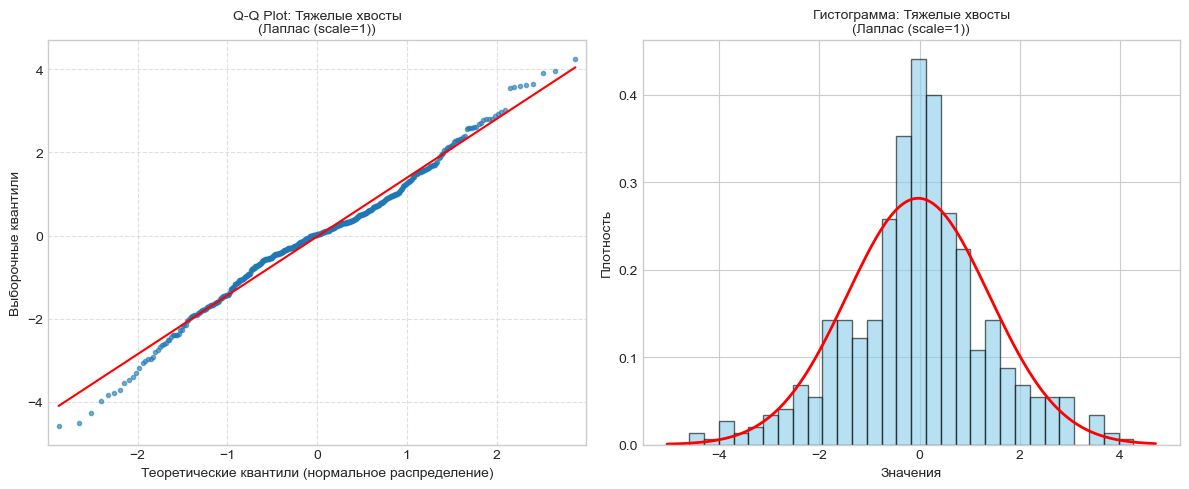

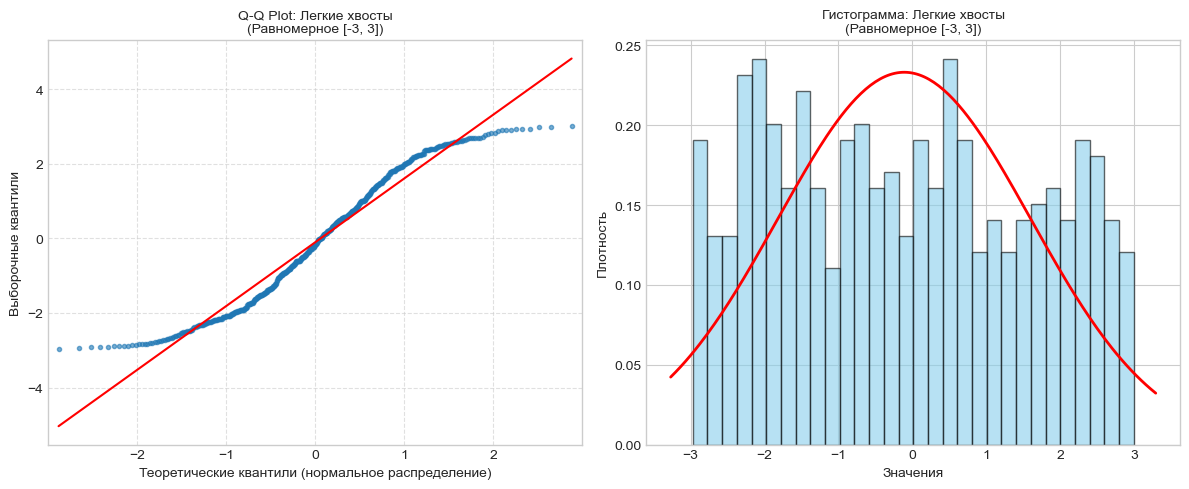

In [3]:
# Тяжелые хвосты (оба конца выше прямой) -> Распределение Лапласа
data1 = stats.laplace.rvs(loc=0, scale=1, size=n)
title = "Тяжелые хвосты"
dist_name = "Лаплас (scale=1)"
qqplot_and_hist(data1, title, dist_name)

# 2. Легкие хвосты -> Равномерное распределение
data2 = np.random.uniform(-3, 3, size=n)
title ="Легкие хвосты"
dist_name = "Равномерное [-3, 3]"
qqplot_and_hist(data2, title, dist_name)

Возьмем три распределения с одинаковой дисперсией (≈ 1):

| Распределение | Тип хвостов | Вероятность $X>3$| Вероятность $X>5$ |
|---------------|-------------|------------|------------|
| Нормальное | Средние (эталон) | $0.00135$ | $2.9×10^{-7}$ |
| Распределение Стьюдента (df=$3$) | Тяжелые | $0.0085$ | $0.0006$ |
| Равномерное $[-\sqrt{3}, \sqrt{3}]$ | Легкие | $0$|$0$ |

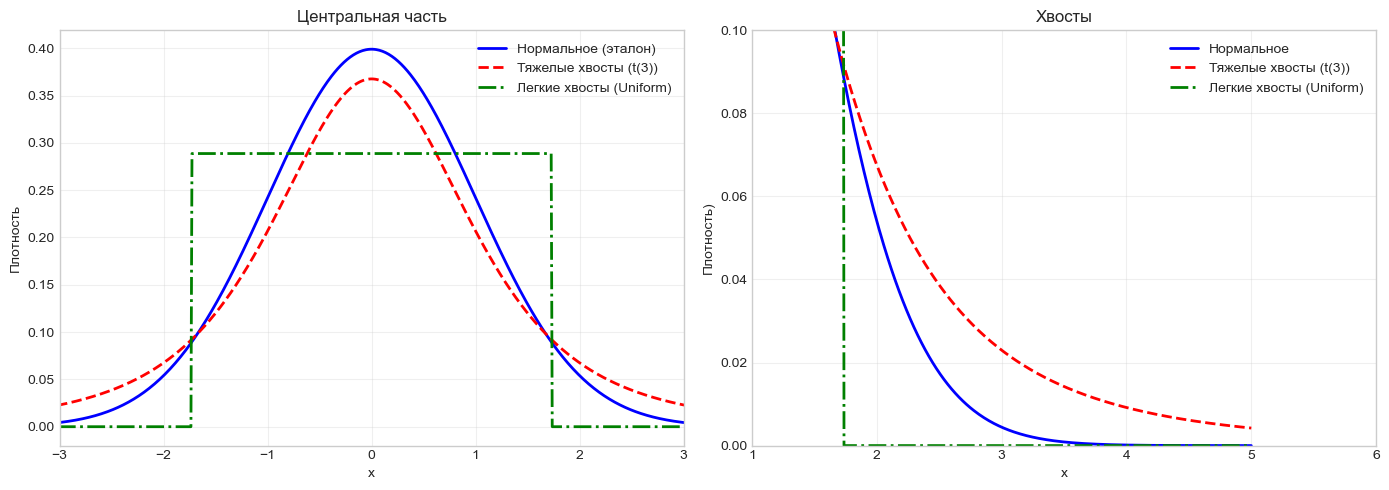

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

np.random.seed(42)

# Генерируем выборки
n = 1000
x = np.linspace(-5, 5, 1000)

# Тяжелые хвосты: распределение Стьюдента с df=3
t3_pdf = stats.t.pdf(x, df=3)

# Легкие хвосты: равномерное распределение (масштабируем для дисперсии 1)
uniform_pdf = stats.uniform.pdf(x, loc=-np.sqrt(3), scale=2*np.sqrt(3))

# Нормальное (эталон)
normal_pdf = stats.norm.pdf(x, loc=0, scale=1)

# Построение графиков плотности
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: центр распределения
axes[0].plot(x, normal_pdf, 'b-', lw=2, label='Нормальное (эталон)')
axes[0].plot(x, t3_pdf, 'r--', lw=2, label='Тяжелые хвосты (t(3))')
axes[0].plot(x, uniform_pdf, 'g-.', lw=2, label='Легкие хвосты (Uniform)')
axes[0].set_xlim(-3, 3)
axes[0].set_title('Центральная часть')
axes[0].set_xlabel('x')
axes[0].set_ylabel('Плотность')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# График 2: хвосты
axes[1].plot(x, normal_pdf, 'b-', lw=2, label='Нормальное')
axes[1].plot(x, t3_pdf, 'r--', lw=2, label='Тяжелые хвосты (t(3))')
axes[1].plot(x, uniform_pdf, 'g-.', lw=2, label='Легкие хвосты (Uniform)')
axes[1].set_xlim(1, 6)
axes[1].set_ylim(0, 0.1)
axes[1].set_title('Хвосты')
axes[1].set_xlabel('x')
axes[1].set_ylabel('Плотность)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**По графикам видно**: у равномерного хвосты обрываются (легкие), у $t(3)$ – вероятность больших значений выше, чем у нормального.

### Случаи отклонения `Q-Q plot` от прямой линии

**Случаи отклонения Q-Q plot от прямой линии** имеют следующую приблизительную интерпретацию.

#### Q-Q plot на обоих концах выше прямой

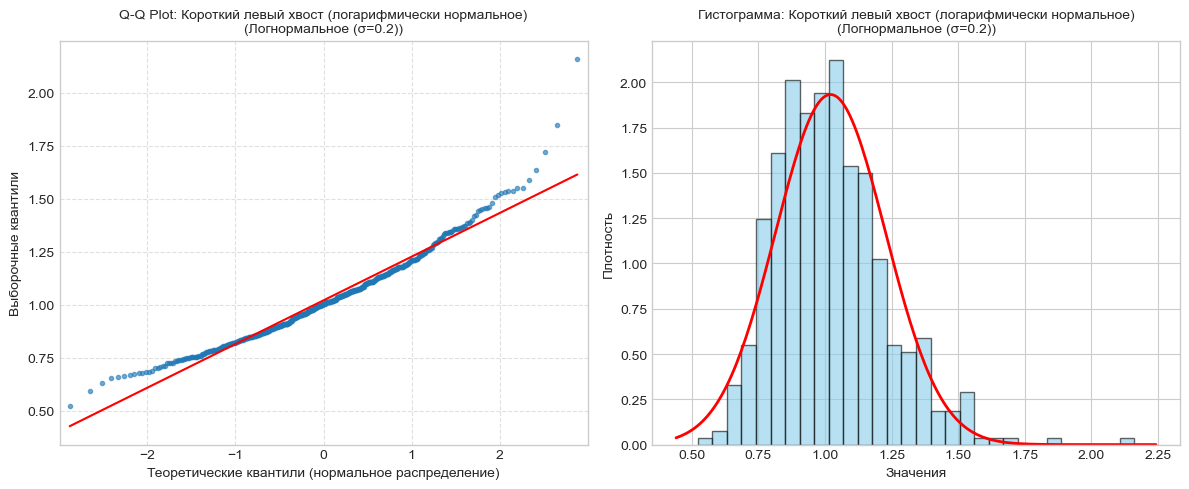

In [3]:
# Логнормальное с очень маленьким параметром формы
data = stats.lognorm.rvs(s=0.2, size=n)
title = "Короткий левый хвост (логарифмически нормальное)"
dist_name = "Логнормальное (σ=0.2)"
qqplot_and_hist(data, title, dist_name)

**Вид графика**: точки лежат над прямой на левом конце (нижние квантили) и на правом конце (верхние квантили). Середина графика близка к прямой.

**Интерпретация**: Для нормального распределения это означает тяжелые хвосты (распределение с большим эксцессом). Выборочные значения на периферии (минимумы и максимумы) больше по модулю, чем у нормальной теории. Т.е. в данных чаще встречаются «выбросоподобные» значения. Как правило, распределение имеет правый перекос.

**Примеры распределений**: Распределение Лапласа, распределение Стьюдента с малыми степенями свободы, логистическое распределение.

**На практике**: процесс дает больше крайних отклонений, чем предсказывает норма. Для статистических выводов (t-тест, ANOVA) нужно быть осторожным – завышенный риск ошибки I рода. 

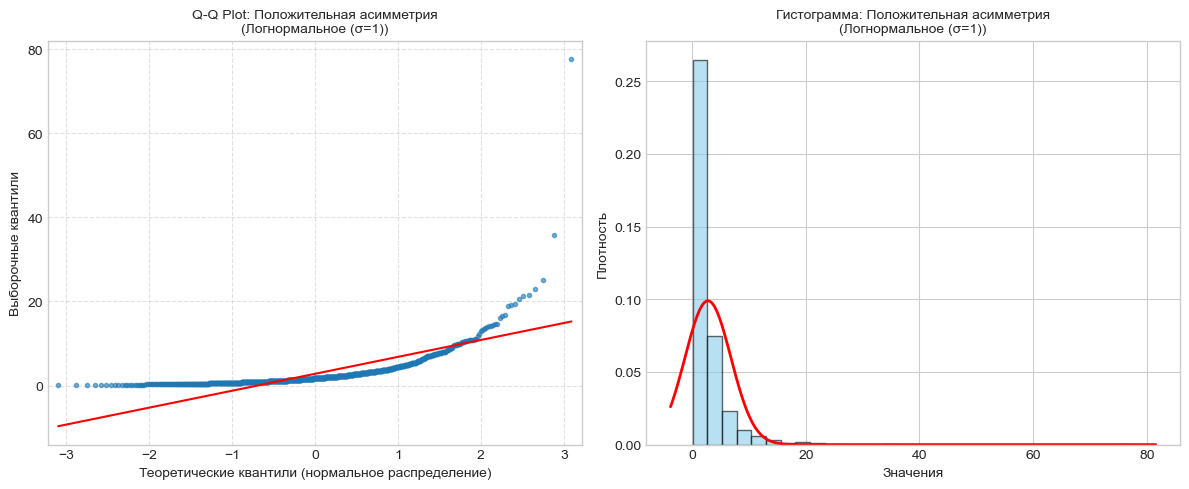

In [11]:
data = stats.lognorm.rvs(s=1.0, loc=0, scale=np.exp(0.5), size=n)
title = "Положительная асимметрия"
dist_name = "Логнормальное (σ=1)"
qqplot_and_hist(data, title, dist_name)

#### Q-Q plot на обоих концах ниже прямой

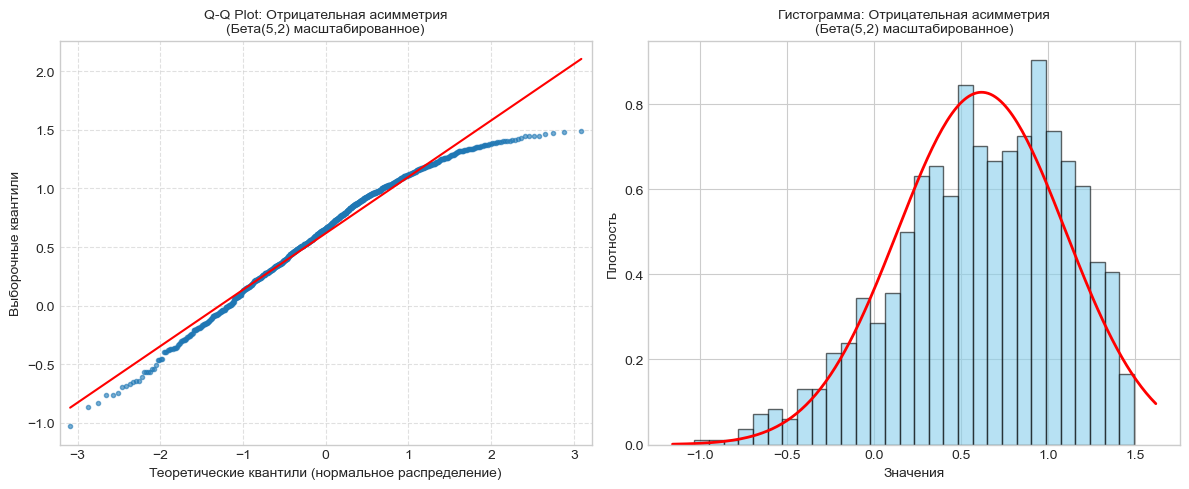

In [13]:
data = stats.beta.rvs(a=5.0, b=2.0, size=n) * 3 - 1.5
title = "Отрицательная асимметрия"
dist_name = "Бета(5,2) масштабированное"
qqplot_and_hist(data, title, dist_name)

**Вид графика**: точки лежат под прямой на левом и правом концах. Центр – примерно на прямой.

**Интерпретация**: легкие хвосты (распределение с отрицательным эксцессом). Наблюдаемые минимумы и максимумы меньше по абсолютной величине, чем у нормального распределения. Данные «скучены» к центру, экстремумы редки и малы. Как правило, распределение имеет левый перекос.

**Примеры распределений**: равномерное распределение, бета-распределение с определенными параметрами, усеченное нормальное.

**На практике**: данные ведут себя более «послушно», чем нормаль. Это реже приводит к ложным выводам при использовании нормальных методов, но может уменьшить мощность критериев (трудно обнаружить реальные различия на хвостах).

#### Q-Q plot имеет S-образную форму

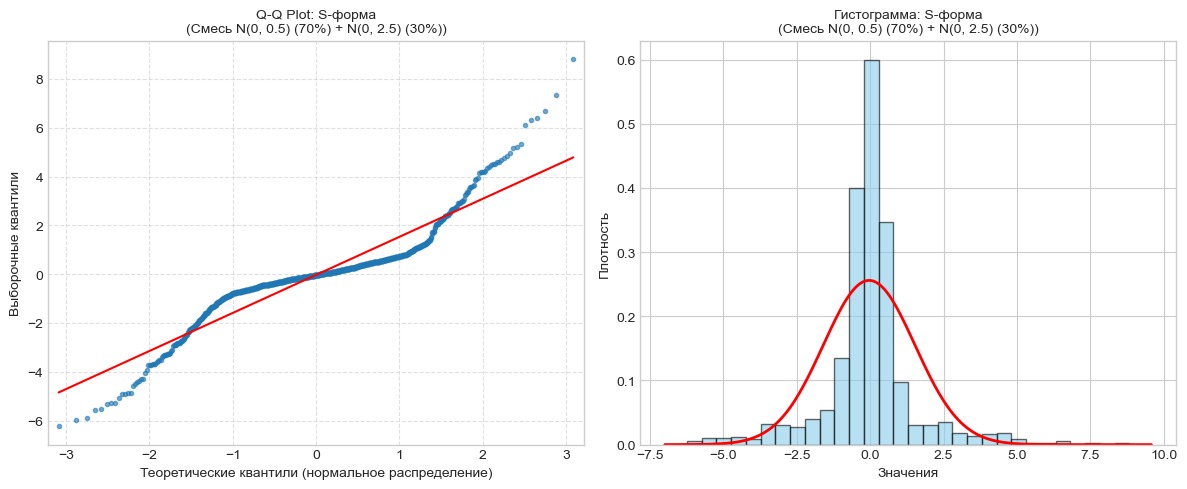

In [21]:
# Параметры смеси: одинаковое среднее (0), разные дисперсии
# 70% данных с малой  сигмой (0.5)
# 30% данных с большой сигмой (2.5)

p_small = 0.7
sigma_small = 0.5
sigma_large = 2.5

n_small = int(n * p_small)
n_large = n - n_small

group_small = np.random.normal(loc=0, scale=sigma_small, size=n_small)
group_large = np.random.normal(loc=0, scale=sigma_large, size=n_large)

data = np.concatenate([group_small, group_large])
title = "S-форма"
dist_name = "Cмесь N(0, 0.5) (70%) + N(0, 2.5) (30%)"
qqplot_and_hist(data, title, dist_name)

**Вид графика**: нижняя часть – точки ниже прямой, затем они пересекают прямую, и верхняя часть снова выше прямой. Вогнутость меняется: сначала выпуклость вверх, затем вниз. Инверсная $S$ (сначала выше, потом ниже) говорит о коротких хвостах.

**Интерпретация**: асимметрия отсутствует (хвосты симметричны), но есть проблема с эксцессом – или наоборот, это признак смеси распределений или двух нормальных компонент с разными дисперсиями. Классический случай: выборка состоит из двух подвыборок с одинаковым средним, но разными дисперсиями. Тогда центральная часть «нормальна», а хвосты «размазаны». 

**На практике**: Стоит проверить данные на наличие группировки. Возможно, смешаны наблюдения от разных процессов. Это один из самых информативных паттернов – он говорит о том, что данные неоднородны по вариабельности, даже если средние одинаковы. В реальных задачах это может означать, что выборка объединяет разные «режимы» работы системы (например, стабильный и изменчивый периоды на финансовом рынке).

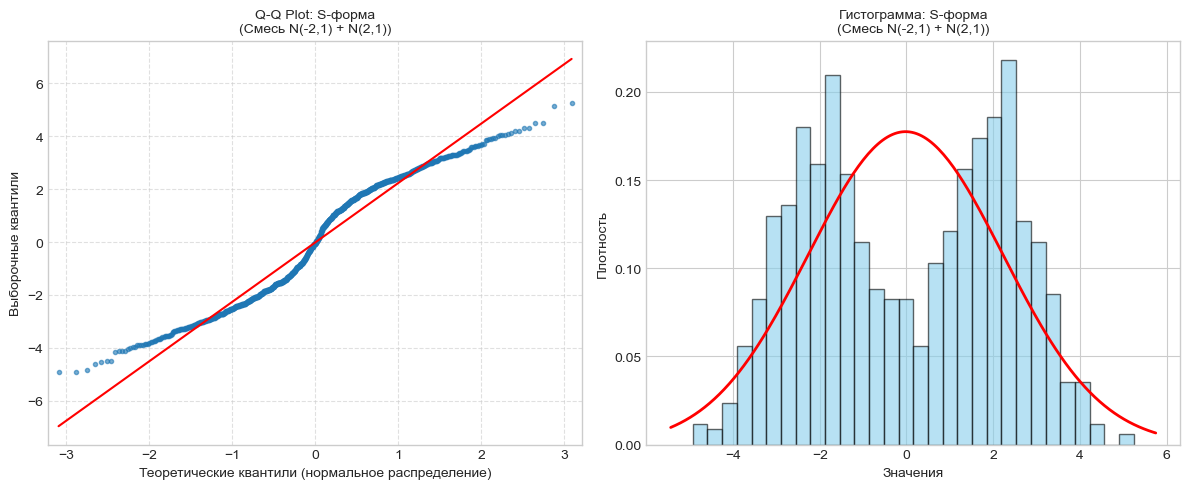

In [18]:
# Два нормальных распределения с разными средними
group1_left = np.random.normal(loc=-2, scale=1, size=n//2)
group2_right = np.random.normal(loc=2, scale=1, size=n - n//2)
data = np.concatenate([group1_left, group2_right])
title = "S-форма"
dist_name = "Cмесь N(-2,1) + N(2,1)"
qqplot_and_hist(data, title, dist_name)

#### Q-Q plot на левом конце ниже прямой, на правом конце – выше прямой

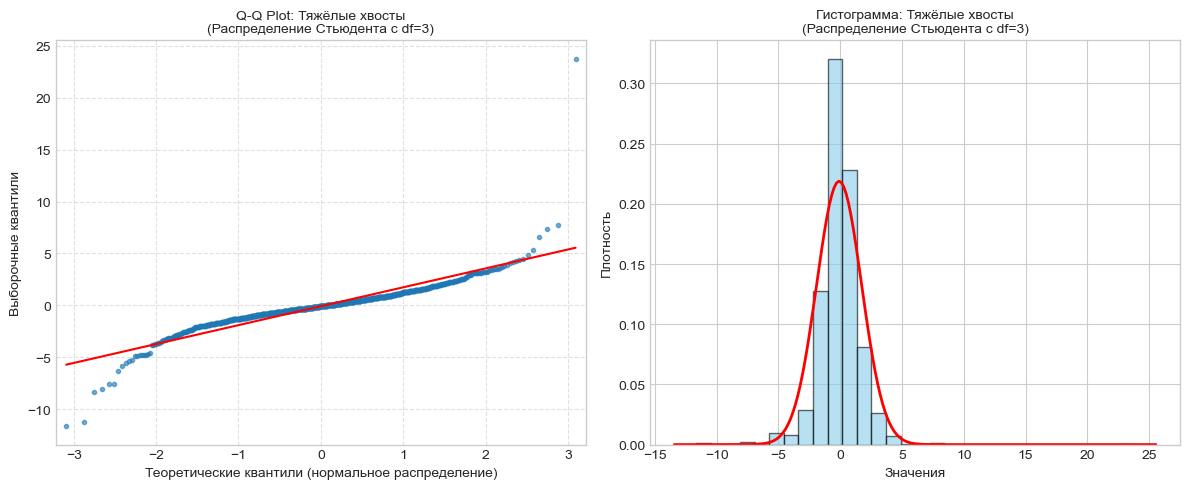

In [28]:
data = stats.t.rvs(df=3, size=n)
title = "Тяжёлые хвосты"
dist_name = "Распределение Стьюдента с df=3"
qqplot_and_hist(data, title, dist_name)

**Вид графика**: левый хвост повернут вниз (точки ниже прямой), правый — вверх (точки выше прямой). Весь график похож на наклонную сигмоиду, несимметричную.

**Интерпретация** это классический признак положительной асимметрии (скошенности вправо). Нижние квантили выборки меньше, чем у симметричного распределения (сжаты слева), а верхние квантили больше (растянуты вправо). Медиана смещена влево относительно среднего.

**Примеры распределений** логнормальное, гамма-распределение с небольшим параметром формы, экспоненциальное, хи-квадрат.

Зеркальный случай (слева выше, справа ниже) даёт отрицательная асимметрия (скошенность влево).

**На практике**: случай, когда `Q-Q plot` на левом конце ниже прямой, на правом конце – выше прямой – самый важный и часто встречающийся на практике паттерн. Этот паттерн возникает в двух принципиально разных ситуациях:

* тяжёлые хвосты (симметричное распределение с высоким эксцессом);
* положительная асимметрия (скошенность вправо).

Различить их можно по поведению центральной части графика.

### Библиотечные функции построения Q-Q plot

#### Собственная реализация построения Q-Q plot

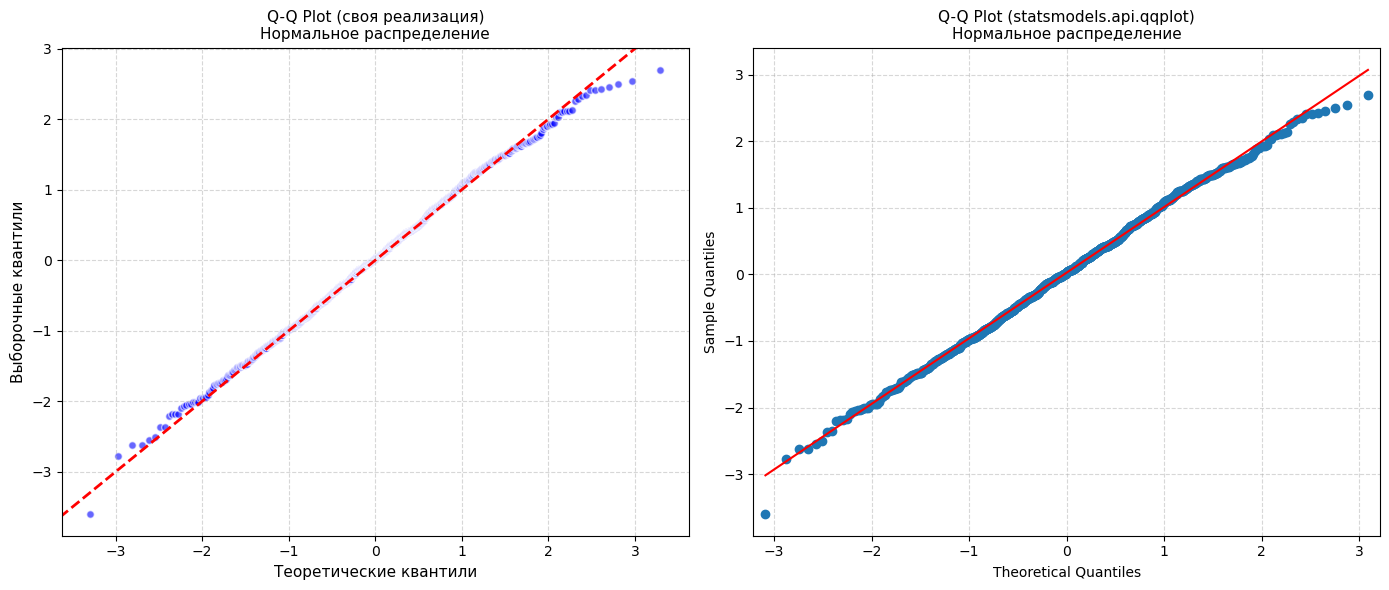

In [17]:
# Ваш код

#### Функция `probplot()` модуля `scipy.stats`

График связи между наблюдаемыми значениями переменной и теоретическими квантилями в модуле `scipy.stats`.

`scipy.stats.probplot(x, sparams=", dist='norm', fit=True, plot=None)`

Параметры: 
* `x` – выборка данных, для которых строится график; 
* `sparams` – кортеж, содержащий все необходимые параметры распределения;
* `dist` – наименование распределения (модуля `scipy.stats` или `statsmodels.distribution`), для которого строятся квантили (по умолчанию `norm` - нормальный);
* `fit` – признак, определяющий, будет ли строиться по выборке линия регрессии,
* `plot` – если присутствует, выводится график квантилей и линия регрессии, иначе график не выводится.

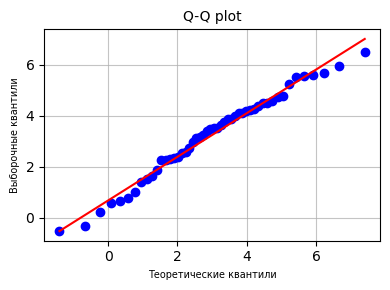

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sts

data = sts.norm.rvs(loc=3.2, scale=1.9, size=50) 

plt.figure(figsize=(4, 3))

# Q-Q plot 
sts.probplot(data, (3.0, 2.0), dist='norm', plot=plt)
plt.title('Q-Q plot', fontsize=10)
plt.grid(axis='both', alpha=0.75)
plt.xlabel('Теоретические квантили', fontsize=7)
plt.ylabel('Выборочные квантили', fontsize=7)

plt.tight_layout()
plt.show();

#### Функция `qqplot()` модуля `statsmodels.api`

График связи между наблюдаемыми значениями переменной и теоретическими квантилями в модуле `statsmodels.api`:

`statsmodels.api.qqplot(data, dist='norm', distargs=(), loc=0, scale=l, fit=False, line=None)`

Параметры: 
* `data` – одномерный массив, распределение которого вы проверяете; 
* `dist` – теоретическое распределение для сравнения. По умолчанию используется `scipy.stats.norm` (стандартное нормальное распределение). Вы можете передать любое другое распределение из модуля `scipy.stats`, например, `stats.t`, `stats.uniform` или `stats.expon`;
* `distargs` – кортеж дополнительных аргументов для выбранного распределения `dist`; 
* `loc` – параметр сдвига (*location*) для теоретического распределения `dist`, по умолчанию $0$;
* `scale` – параметр масштаба (*scale*) для теоретического распределения `dist`, по умолчанию $1$;
* `fit` – если `False`, в распределении используются параметры `distags`, `loc` и `scale`, если `True`, параметры оцениваются методом `dist.fit`; 
* `line` – линия, с которой сравниваются данные: $45$ – прямая под углом в 45°, `s` – стандартизованная прямая, вычисляемая через порядковые статстистики, `r` – линия регрессии, `q` – линия, оцениваемая через квартили.

<Figure size 400x300 with 0 Axes>

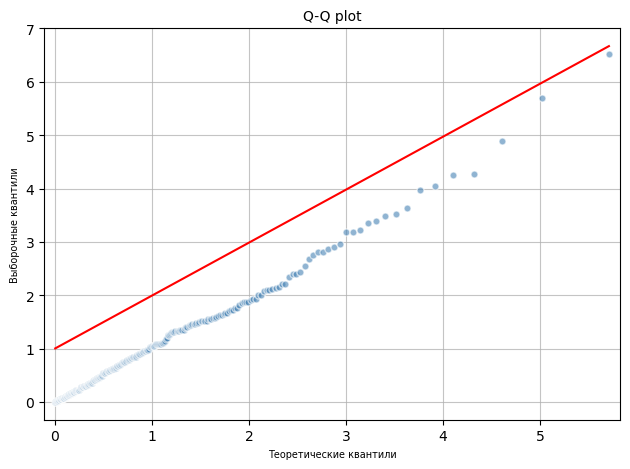

In [4]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import scipy.stats as stats

data = np.random.exponential(scale=2, size=300)  # экспоненциальное распределение

plt.figure(figsize=(4, 3))

# Q-Q plot 
fig = sm.qqplot(data,          # данные
                dist=stats.expon,  # сравниваем с экспоненциальным распределением
                line='s',      # добавляем линию через квартили
                marker='o',    # форма маркера
                markerfacecolor='steelblue',  # цвет маркеров
                markeredgecolor='white',      # обводка
                markersize=5,  # размер маркеров
                alpha=0.6,  # прозрачность
                fit=True
               )     
plt.title('Q-Q plot', fontsize=10)
plt.grid(axis='both', alpha=0.75)
plt.xlabel('Теоретические квантили', fontsize=7)
plt.ylabel('Выборочные квантили', fontsize=7)

plt.tight_layout()
plt.show();